#  Tầng 3b: Multiple Answer Analysis — Checkbox Questions

**Mục tiêu:** Thống kê tần suất & vẽ Bar chart ngang / Pareto cho các câu hỏi Checkbox.  
Trả lời: Công cụ nào phổ biến nhất? Rào cản lớn nhất? Lợi ích kỳ vọng?

**Input:** `multiple_answers_processed.csv`  
**Output:** Biểu đồ lưu vào `output/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os
from pathlib import Path

# ══════════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════════

os.makedirs("output", exist_ok=True)

matplotlib.rcParams["font.family"] = "Arial"
matplotlib.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", palette="muted", font="Arial")

INPUT_FILE = "multiple_answers_processed.csv"
assert Path(INPUT_FILE).exists(), f" Chưa có {INPUT_FILE}!"
df = pd.read_csv(INPUT_FILE, encoding="utf-8-sig")
N = len(df)
print(f" Đọc {INPUT_FILE}: {N} responses × {df.shape[1]} cột")

# Lấy danh sách checkbox prefixes
dummy_cols = [c for c in df.columns if "__" in c]
prefixes = sorted(set(c.split("__")[0] for c in dummy_cols))
print(f" Checkbox questions: {len(prefixes)}")
for p in prefixes:
    n_opts = sum(1 for c in dummy_cols if c.startswith(f"{p}__"))
    print(f"   • {p} ({n_opts} options)")

 Đọc multiple_answers_processed.csv: 151 responses × 114 cột
 Checkbox questions: 8
   • Q10_cicd_benefits (6 options)
   • Q33_cicd_difficulties (9 options)
   • Q34_adoption_barriers (12 options)
   • Q39_biggest_barrier (10 options)
   • Q40_expected_benefit (7 options)
   • Q4_product_field (14 options)
   • Q7_tools_used (7 options)
   • Q9_usage_purpose (8 options)


In [2]:
# ══════════════════════════════════════════════════════════
# HÀM TIỆN ÍCH
# ══════════════════════════════════════════════════════════

def get_checkbox_freq(df, prefix):
    """
    Tính tần suất cho 1 nhóm checkbox (vectorized).
    Returns: pd.Series sorted descending.
    """
    cols = [c for c in df.columns if c.startswith(f"{prefix}__")]
    freq = df[cols].sum().sort_values(ascending=False)
    # Tên ngắn gọn (bỏ prefix)
    freq.index = [c.replace(f"{prefix}__", "") for c in freq.index]
    return freq


def plot_checkbox_bar(df, prefix, title, filename,
                      figsize=(12, 6), top_n=None, palette="coolwarm_r"):
    """
    Bar chart ngang cho checkbox question.
    Hiển thị count + % trên tổng N.
    """
    freq = get_checkbox_freq(df, prefix)
    if top_n:
        freq = freq.head(top_n)

    pcts = (freq / N * 100).round(1)

    # Wrap text dài
    labels = [label if len(label) <= 55 else label[:52] + "..." for label in freq.index]

    fig, ax = plt.subplots(figsize=figsize)
    colors = sns.color_palette(palette, len(freq))
    bars = ax.barh(range(len(freq)), freq.values, color=colors,
                   edgecolor="white", linewidth=0.8)

    ax.set_yticks(range(len(freq)))
    ax.set_yticklabels(labels, fontsize=8.5)
    ax.invert_yaxis()

    for i, (val, pct) in enumerate(zip(freq.values, pcts.values)):
        ax.text(val + freq.max() * 0.02, i, f"{val} ({pct}%)",
                va="center", fontsize=9, fontweight="bold")

    ax.set_xlabel(f"Số lần được chọn (trên {N} người)", fontsize=10)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlim(0, freq.max() * 1.3)
    sns.despine(left=True)

    plt.tight_layout()
    plt.savefig(f"output/{filename}", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"    Saved: output/{filename}")


def plot_pareto(df, prefix, title, filename, figsize=(12, 6), top_n=None):
    """
    Biểu đồ Pareto: Bar (tần suất) + Line (cumulative %).
    """
    freq = get_checkbox_freq(df, prefix)
    if top_n:
        freq = freq.head(top_n)

    cum_pct = (freq.cumsum() / freq.sum() * 100).values

    labels = [l if len(l) <= 50 else l[:47] + "..." for l in freq.index]

    fig, ax1 = plt.subplots(figsize=figsize)

    # Bar chart
    colors = sns.color_palette("Blues_d", len(freq))
    bars = ax1.bar(range(len(freq)), freq.values, color=colors,
                   edgecolor="white", linewidth=0.8)
    ax1.set_xticks(range(len(freq)))
    ax1.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
    ax1.set_ylabel("Tần suất", fontsize=10)

    # Cumulative line (twin axis)
    ax2 = ax1.twinx()
    ax2.plot(range(len(freq)), cum_pct, color="#E74C3C", marker="o",
             linewidth=2, markersize=6, markerfacecolor="white",
             markeredgecolor="#E74C3C", markeredgewidth=2)
    ax2.set_ylabel("% Tích lũy", fontsize=10, color="#E74C3C")
    ax2.set_ylim(0, 105)
    ax2.axhline(y=80, color="#E74C3C", linestyle="--", alpha=0.4, label="80% Pareto")
    ax2.legend(loc="center right", fontsize=9)

    # Annotation on bars
    for i, val in enumerate(freq.values):
        ax1.text(i, val + freq.max() * 0.02, str(val),
                 ha="center", fontsize=9, fontweight="bold")

    ax1.set_title(title, fontsize=13, fontweight="bold", pad=12)
    sns.despine(right=False)

    plt.tight_layout()
    plt.savefig(f"output/{filename}", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"    Saved: output/{filename}")

print(" Các hàm tiện ích đã sẵn sàng")

 Các hàm tiện ích đã sẵn sàng


---
##  Q7: Công cụ CI/CD đã sử dụng

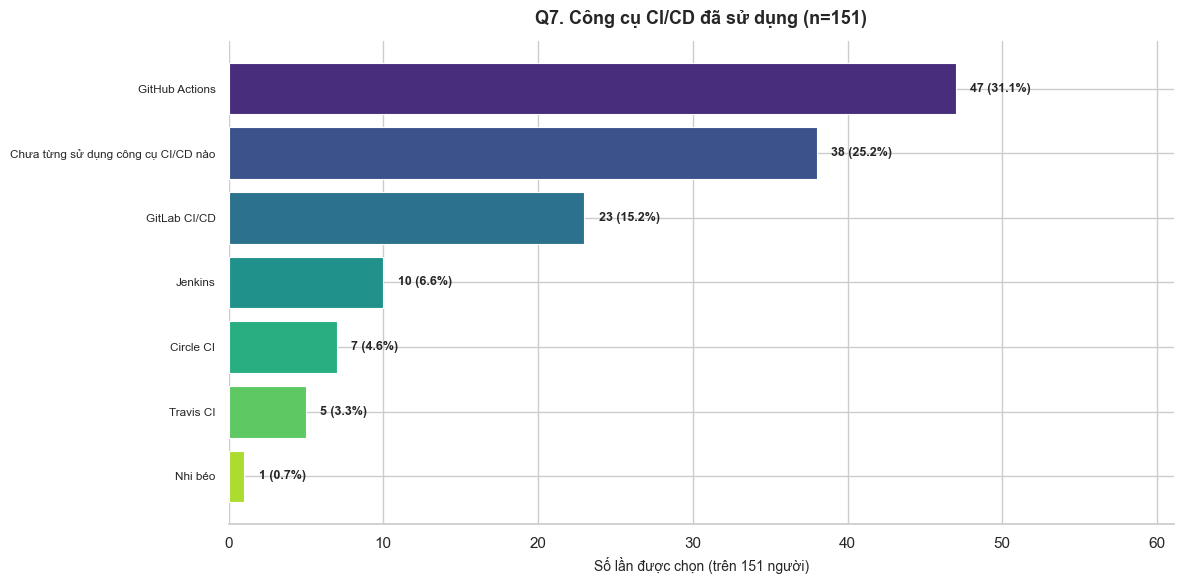

    Saved: output/Q7_tools_used_bar.png


In [3]:
plot_checkbox_bar(df, "Q7_tools_used",
                  title=f"Q7. Công cụ CI/CD đã sử dụng (n={N})",
                  filename="Q7_tools_used_bar.png",
                  palette="viridis")

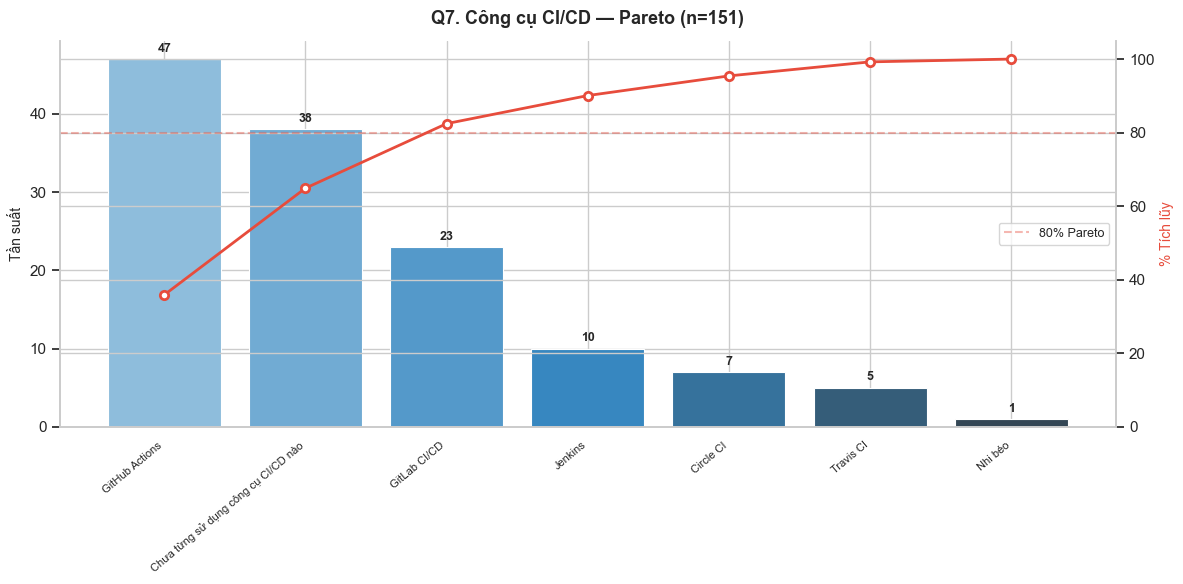

    Saved: output/Q7_tools_used_pareto.png


In [4]:
plot_pareto(df, "Q7_tools_used",
            title=f"Q7. Công cụ CI/CD — Pareto (n={N})",
            filename="Q7_tools_used_pareto.png")

---
##  Q9: Mục đích sử dụng CI/CD

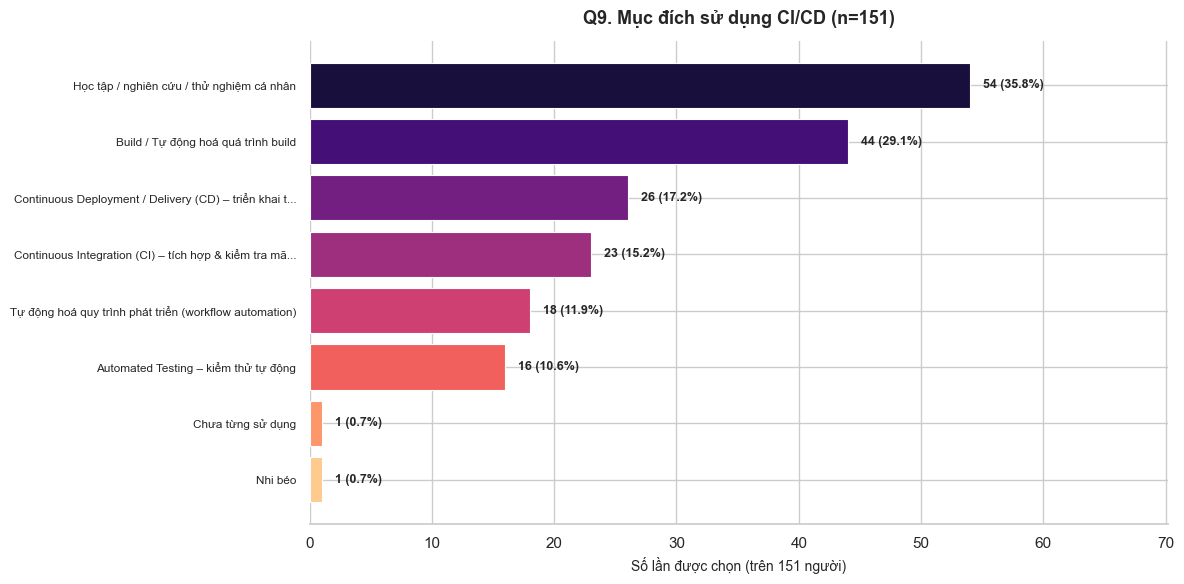

    Saved: output/Q9_usage_purpose_bar.png


In [5]:
plot_checkbox_bar(df, "Q9_usage_purpose",
                  title=f"Q9. Mục đích sử dụng CI/CD (n={N})",
                  filename="Q9_usage_purpose_bar.png",
                  palette="magma")

---
##  Q10: Lợi ích CI/CD đem lại

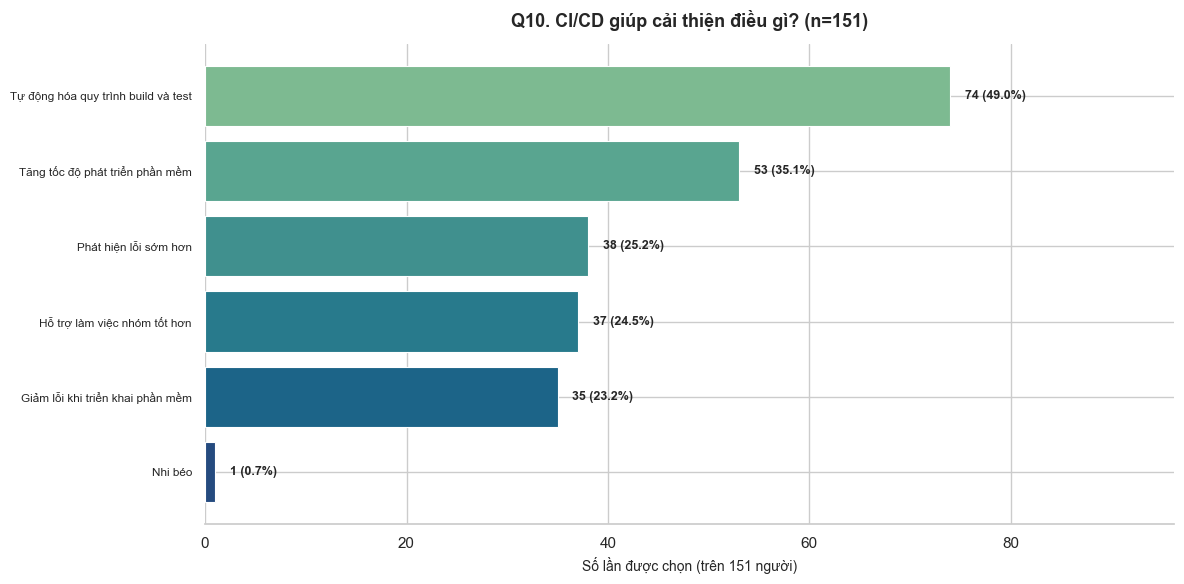

    Saved: output/Q10_cicd_benefits_bar.png


In [6]:
plot_checkbox_bar(df, "Q10_cicd_benefits",
                  title=f"Q10. CI/CD giúp cải thiện điều gì? (n={N})",
                  filename="Q10_cicd_benefits_bar.png",
                  palette="crest")

---
##  Q33: Giai đoạn CI/CD gặp khó khăn

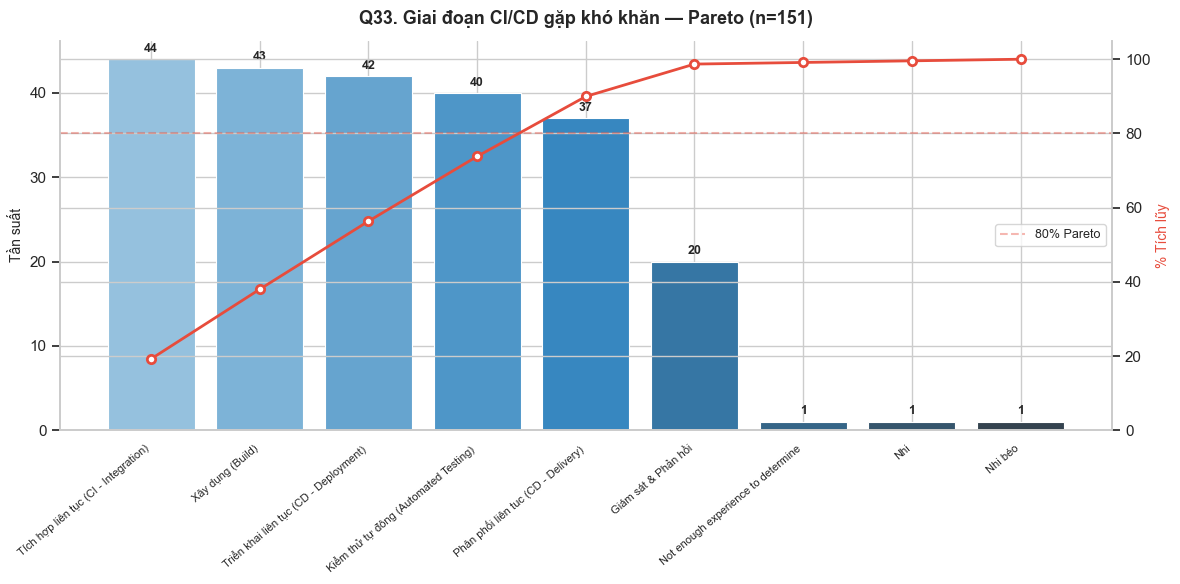

    Saved: output/Q33_cicd_difficulties_pareto.png


In [7]:
plot_pareto(df, "Q33_cicd_difficulties",
            title=f"Q33. Giai đoạn CI/CD gặp khó khăn — Pareto (n={N})",
            filename="Q33_cicd_difficulties_pareto.png")

---
##  Q34: Rào cản khiến SV khó áp dụng CI/CD

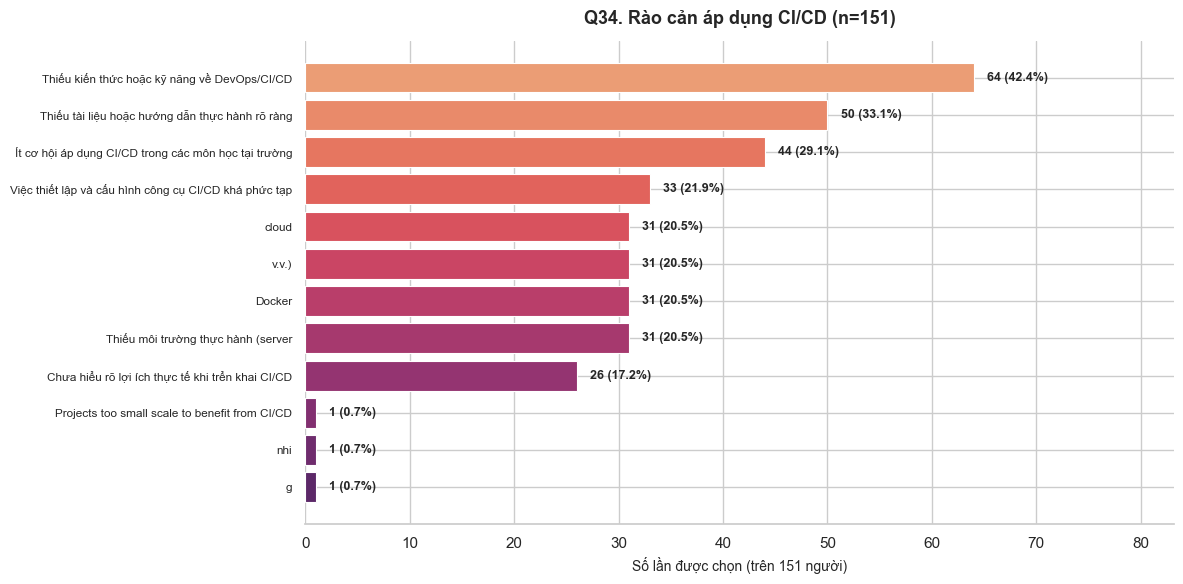

    Saved: output/Q34_adoption_barriers_bar.png


In [8]:
plot_checkbox_bar(df, "Q34_adoption_barriers",
                  title=f"Q34. Rào cản áp dụng CI/CD (n={N})",
                  filename="Q34_adoption_barriers_bar.png",
                  palette="flare")

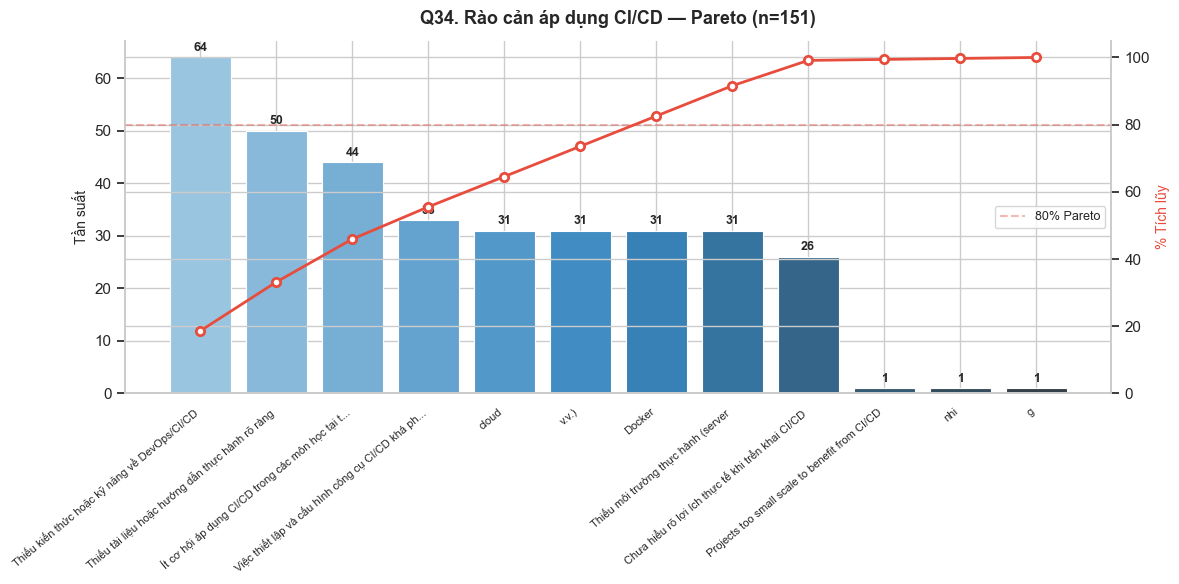

    Saved: output/Q34_adoption_barriers_pareto.png


In [9]:
plot_pareto(df, "Q34_adoption_barriers",
            title=f"Q34. Rào cản áp dụng CI/CD — Pareto (n={N})",
            filename="Q34_adoption_barriers_pareto.png")

---
##  Q39: Rào cản lớn nhất

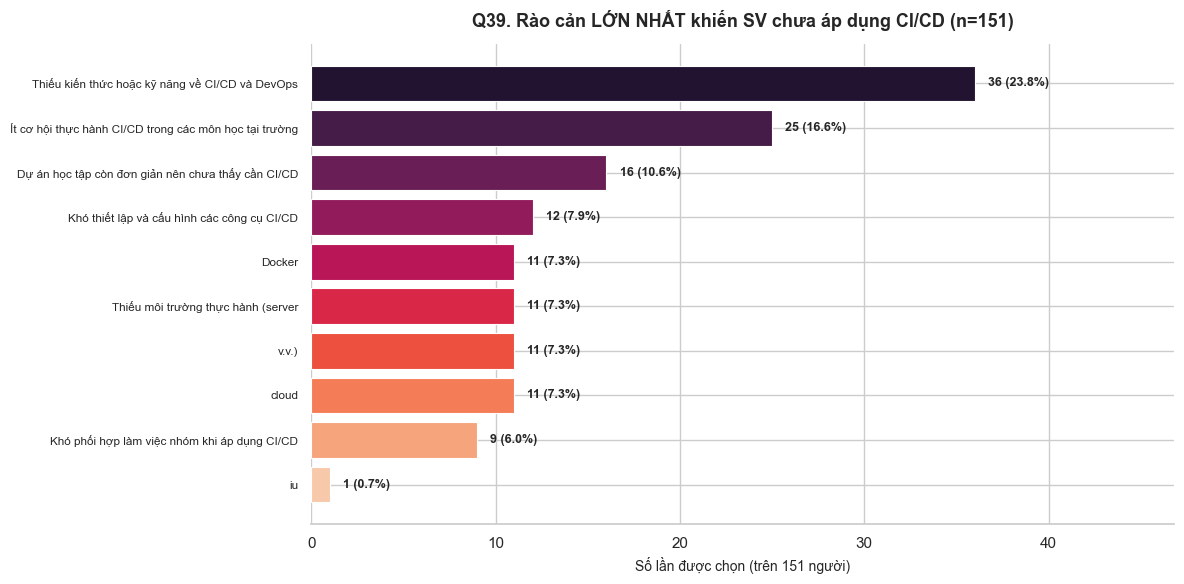

    Saved: output/Q39_biggest_barrier_bar.png


In [10]:
plot_checkbox_bar(df, "Q39_biggest_barrier",
                  title=f"Q39. Rào cản LỚN NHẤT khiến SV chưa áp dụng CI/CD (n={N})",
                  filename="Q39_biggest_barrier_bar.png",
                  palette="rocket")

---
##  Q40: Lợi ích kỳ vọng nhất

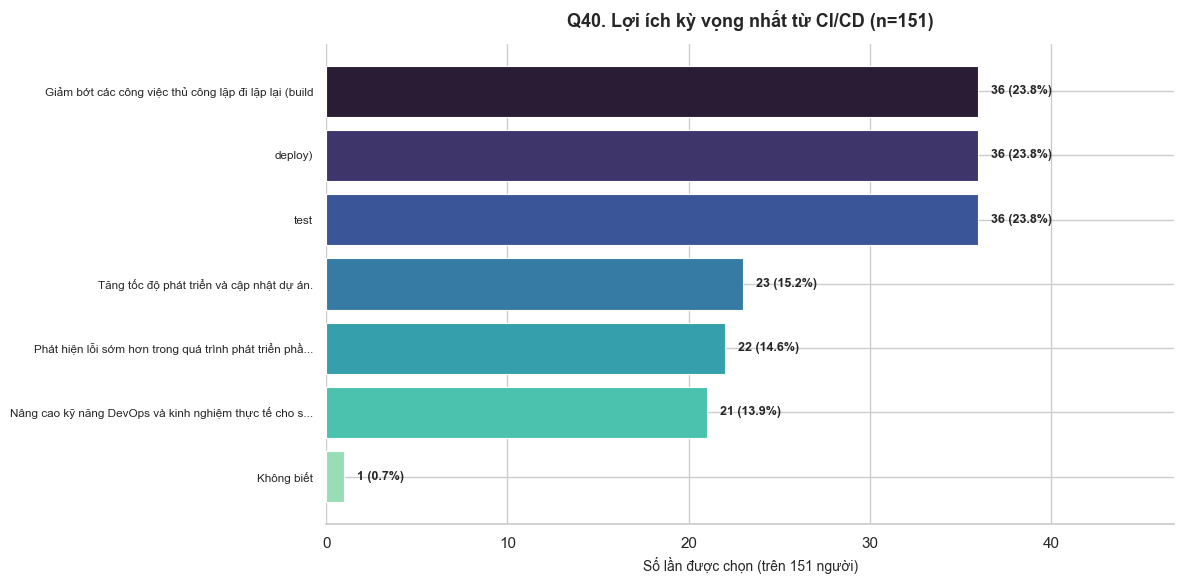

    Saved: output/Q40_expected_benefit_bar.png


In [11]:
plot_checkbox_bar(df, "Q40_expected_benefit",
                  title=f"Q40. Lợi ích kỳ vọng nhất từ CI/CD (n={N})",
                  filename="Q40_expected_benefit_bar.png",
                  palette="mako")

---
##  Q4: Lĩnh vực sản phẩm (cũng là checkbox)

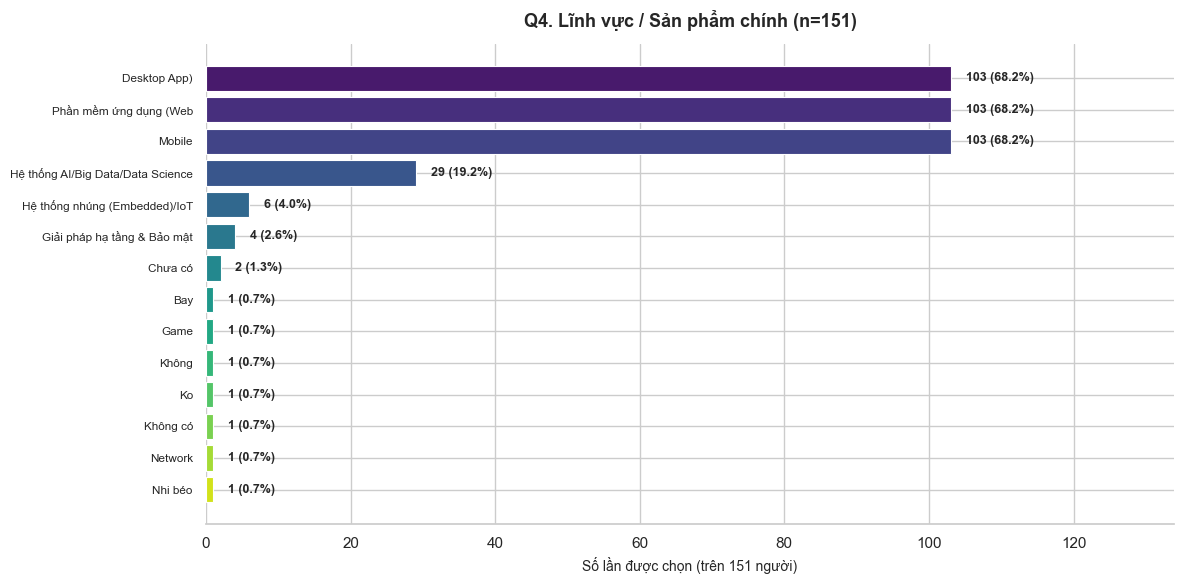

    Saved: output/Q4_product_field_bar.png


In [12]:
plot_checkbox_bar(df, "Q4_product_field",
                  title=f"Q4. Lĩnh vực / Sản phẩm chính (n={N})",
                  filename="Q4_product_field_bar.png",
                  palette="viridis")

In [ ]:
# ══════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════

output_files = sorted([f for f in os.listdir("output") if f.endswith(".png")])
# Chỉ đếm file thuộc notebook này
my_files = [f for f in output_files if any(
    f.startswith(p) for p in ["Q4_", "Q7_", "Q9_", "Q10_", "Q33_", "Q34_", "Q39_", "Q40_"]
)]
print(f"\n{'═'*50}")
print(f" HOÀN TẤT: 2b_multiple_answer_analysis")
print(f"   Biểu đồ mới tạo: {len(my_files)} file")
for f in my_files:
    size_kb = os.path.getsize(f'output/{f}') / 1024
    print(f"    {f} ({size_kb:.0f} KB)")
print(f"   Tổng file trong output/: {len(output_files)}")
print(f"{'═'*50}")


══════════════════════════════════════════════════
✅ HOÀN TẤT: 2b_multiple_answer_analysis
   Biểu đồ mới tạo: 10 file
   📈 Q10_cicd_benefits_bar.png (56 KB)
   📈 Q33_cicd_difficulties_pareto.png (108 KB)
   📈 Q34_adoption_barriers_bar.png (90 KB)
   📈 Q34_adoption_barriers_pareto.png (128 KB)
   📈 Q39_biggest_barrier_bar.png (81 KB)
   📈 Q40_expected_benefit_bar.png (66 KB)
   📈 Q4_product_field_bar.png (80 KB)
   📈 Q7_tools_used_bar.png (53 KB)
   📈 Q7_tools_used_pareto.png (77 KB)
   📈 Q9_usage_purpose_bar.png (74 KB)
   Tổng file trong output/: 27
══════════════════════════════════════════════════
